In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from preprocessing import OneHotEncoder

### EDA

In [2]:
train_data = pd.read_csv("../data/mnist_train.csv")
test_data = pd.read_csv("../data/mnist_test.csv")
train_data.head(100)

,label,1x1,1x2,1x3,1x4,1x5,1x6,1x7,1x8,1x9,...,28x19,28x20,28x21,28x22,28x23,28x24,28x25,28x26,28x27,28x28
0,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
96,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
97,8,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
98,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [3]:
test_data.head(100)

,label,1x1,1x2,1x3,1x4,1x5,1x6,1x7,1x8,1x9,...,28x19,28x20,28x21,28x22,28x23,28x24,28x25,28x26,28x27,28x28
0,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
96,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
97,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
98,6,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [4]:
train_data = np.array(train_data, dtype=np.float32)
test_data = np.array(test_data, dtype=np.float32)
m, n = train_data.shape
m, n

(60000, 785)

In [5]:
# reshaping from 785 to 784 dimension then into 28x28 greyscale and removing 1 label column.
image_data = train_data[:, 1:].reshape(-1, 28, 28)
image_data.shape

(60000, 28, 28)

In [6]:
# function to display 0 - 9 images
def show_image(dataset):
    i = 0
    while(i < 10):
        i+=1
        plt.imshow(image_data[i], cmap="gray", vmin=0, vmax=255)
        plt.colorbar()
        plt.show()

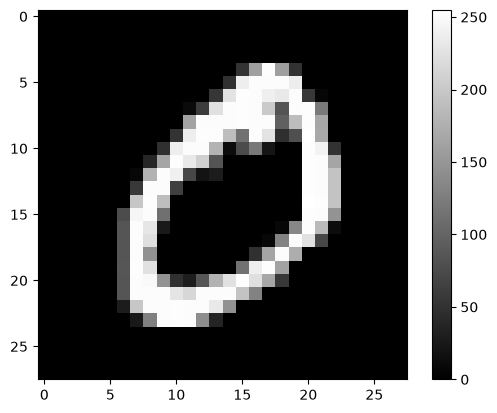

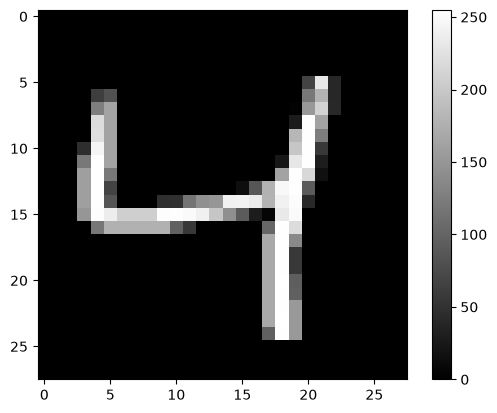

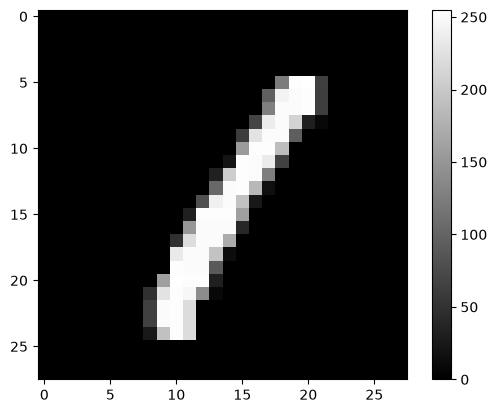

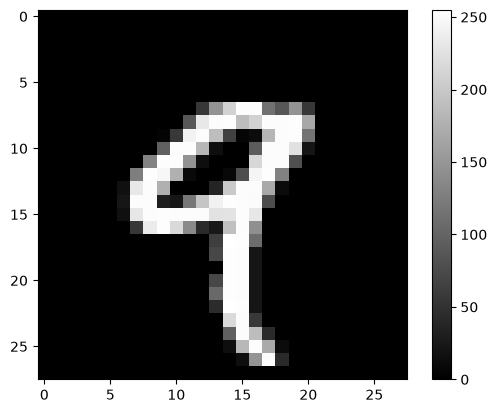

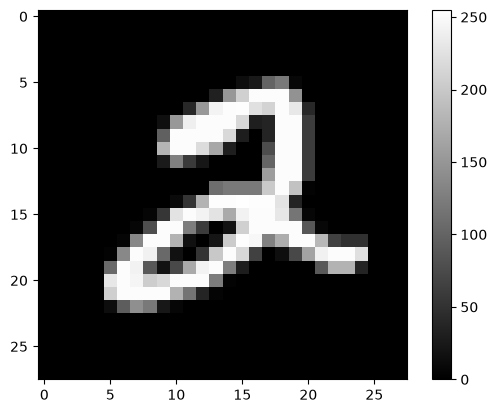

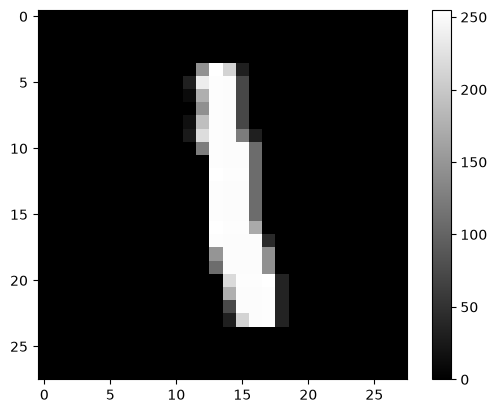

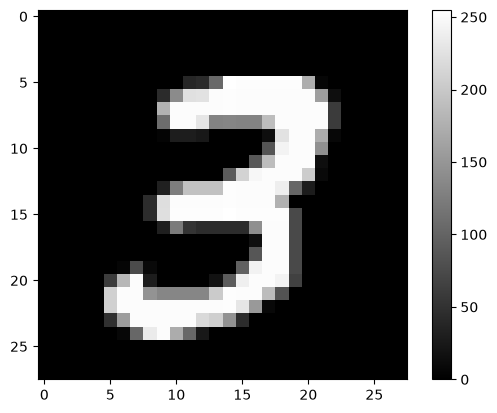

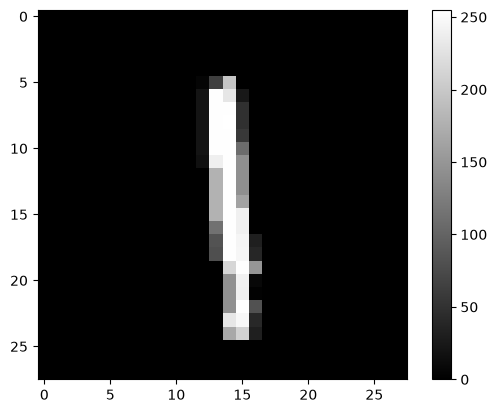

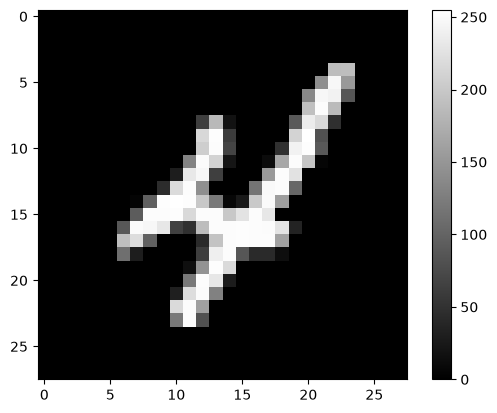

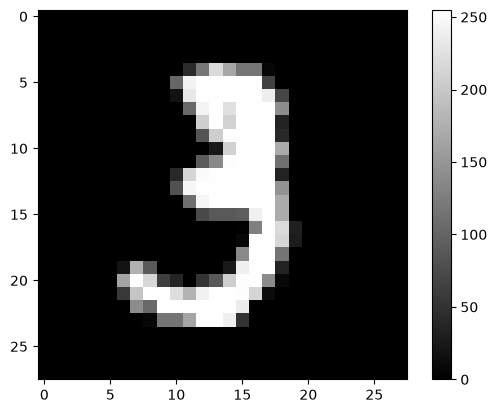

In [7]:
show_image(image_data)

### Data Preperation and Preprocessing

In [8]:
len(train_data), len(test_data), train_data.shape

(60000, 10000, (60000, 785))

In [9]:
X_train, y_train, X_test, y_test = train_data[:, 1:], train_data[:, 0], test_data[:, 1:], test_data[:, 0]

In [10]:
len(X_train), len(y_train), len(X_test), len(y_test)

(60000, 60000, 10000, 10000)

In [11]:
# One Hot encoding the Labels of training and test data
y_train = OneHotEncoder(train_data[:, 0], dtype=int)
y_test = OneHotEncoder(test_data[:, 0], dtype=int)
y_train, y_test

(array([[0, 0, 0, ..., 0, 0, 0],
        [1, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 1, 0]], shape=(60000, 10)),
 array([[0, 0, 0, ..., 1, 0, 0],
        [0, 0, 1, ..., 0, 0, 0],
        [0, 1, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]], shape=(10000, 10)))

In [12]:
y_train.shape, y_test.shape

((60000, 10), (10000, 10))

### MODEL
We'll use `MultiLayer Perceptron` for classifying MNIST data.

In [27]:
from models import MultiLayerPerceptron
from core.loss import CCE
from core.optim import SGD
from core.activation import softmax

model = MultiLayerPerceptron()
loss_fn = CCE()
optimizer = SGD(model, lr = 0.05)
activation = softmax()

In [ ]:
# Training and testing loop
epochs = 100
training_losses = []
test_losses = []
for epoch in range(epochs):
    y_logits = model(X_train)
    #y_preds = activation(y_logits)
    loss = loss_fn(y_logits, y_train)
    optimizer.zero_grad()
    loss_fn.backward(model)
    optimizer.step()
    test_logits = model(X_test)
    test_pred = activation(test_logits)
    test_loss = loss_fn(test_logits, y_test)
    if epoch % 10 == 0:
        training_losses.append(loss)
        test_losses.append(test_loss)
        print(f"Epoch: {epoch} | Train Loss: {loss:.5f} | Test loss: {test_loss:.5f}")

plt.figure(figsize=(6, 4))
plt.plot(range(0, epochs, 10), training_losses, label="Training loss", color="blue", linewidth=2)
plt.plot(range(0, epochs, 10), test_losses, label="Test loss", color="red", linestyle="--", linewidth=2)
plt.title("Training and testing loss over Epochs")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

Epoch: 0 | Train Loss: 2.30258 | Test loss: 2.30250
Epoch: 10 | Train Loss: 2.30242 | Test loss: 2.30233
Epoch: 20 | Train Loss: 2.30227 | Test loss: 2.30218
Epoch: 30 | Train Loss: 2.30212 | Test loss: 2.30203
Epoch: 40 | Train Loss: 2.30198 | Test loss: 2.30189
